# Оценка дообученной модели SuperPoint по метрике M_k

Оценим дообученную модель также по метрике $ M_5 $ при различных ограничениях максимального числа извлекаемых точек. Для этого на 200 изображениях (со смещением ~ 1 м между кадрами) для каждого окна из 5 кадров вычислим значение метрики, а затем найдём среднее по всем вычислениям.

In [ ]:
# Импорт необходимых библиотек
import cv2
import numpy as np
import torch
import yaml
import sys

# Добавление пути для импорта модулей
sys.path.append("retrained_superpoint")

In [4]:
from retrained_superpoint.utils.loader import dataLoader
from retrained_superpoint.models.model_wrap import PointTracker
from retrained_superpoint.models.ValidationModel import Val_model_heatmap

In [ ]:
class SuperPointRetrained:
    def __init__(self, config_path: str):
        """Инициализация класса SuperPointRetrained.

        Parameters
        ----------
        config_path : str
            путь к файлу конфигурации
        """
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.config = self.load_config(config_path)
        self.data = self.load_data()
        self.val_agent = self.initialize_model()
        self.point_tracker = self.initialize_tracker()

    def load_config(self, config_path: str):
        """Загрузка конфигурации
        
        Parameters
        ----------
        config_path : str
            путь к файлу конфигурации
        """
        with open(config_path, 'r') as f:
            return yaml.safe_load(f)

    def load_data(self):
        """Загрузка данных для валидации"""
        return dataLoader(self.config, dataset='ValidateDataset')

    def initialize_model(self):
        """Инициализация модели для валидации"""
        val_agent = Val_model_heatmap(self.config['model'], device=self.device)
        val_agent.loadModel()
        return val_agent
    
    def initialize_tracker(self):
        """Инициализация трекера точек"""
        return PointTracker(nn_thresh=self.val_agent.nn_thresh)

    def detect_and_compute(self, sample):
        """Находит ключевые точки на изображении
        и вычисляет для каждой точки дескриптор.

        Parameters
        ----------
        sample : dict
            словарь с информацией о изображении
        """
        pts, desc = self.val_agent.get_keypoints_and_descriptors(sample)
        return pts, desc
    
    def matches(self, pts1, pts2, desc1, desc2):
        """Находит сопоставления для дескрипторов точек.

        Parameters
        ----------
        pts1 : numpy.ndarray
            ключевые точки первого изображения
         pts2 : numpy.ndarray
            ключевые точки второго изображения
         desc1 : numpy.ndarray
            дескрипторы ключевых точек первого изображения
         desc2 : numpy.ndarray
            дескрипторы ключевых точек второго изображения
        """
        self.point_tracker.update(pts1, desc1)
        self.point_tracker.update(pts2, desc2)
        matches = np.array(self.point_tracker.get_mscores()).transpose()
        return self.format_matches(matches)

    def format_matches(self, matches):
        """Форматирует сопоставления в список объектов cv2.DMatch.

        Parameters
        ----------
        matches : numpy.ndarray
            массив сопоставлений
        """
        dmatches = []
        
        for i in range(matches.shape[0]):
            dmatch = cv2.DMatch()
            dmatch.queryIdx = int(matches[i, 0])
            dmatch.trainIdx = int(matches[i, 1])
            dmatch.distance = matches[i, 2]
            dmatches.append(dmatch)
        
        return dmatches

In [ ]:
def run_experiment_for_retrained(config_path, alpha, k=3, num_images=None):
    """Вычисляет среднее значение метрики М_k для дообученной модели SuperPoint

    Parameters
    ----------
    config_path : str
        путь до конфига с параметрами
    alpha : float
        коэффицент различающейся площади между кадрами
    k : int
        размер окна (по умолчанию 3)
    num_images : int, optional
        количество изображений для сравнения (по умолчанию будут взяты все)
    """
    retrained_sp = SuperPointRetrained(config_path)  # Инициализация модели
    all_frames = list(retrained_sp.data['test_loader'])

    retrained_sp_sum_all = []
    retrained_sp_av = []

    # Вычисление индекса для итерации по изображениям
    range_num = num_images - k + 1 if num_images else len(all_frames) - k + 1

    for i in range(range_num):
        # Извлечение ключевых точек и дескрипторов для первого изображения окна
        retrained_sp_kp0, retrained_sp_des0 = retrained_sp.detect_and_compute(all_frames[i])
        k_sum_retrained_sp = 0

        # Добавление количества извлеченных точек на изображении в список
        retrained_sp_av.append(retrained_sp_kp0.shape[1])

        # Проход по окну
        for j in range(1, k):
            # Вычисление для j-ого кадра окна ключевых точек и дескрипторов
            retrained_sp_kp, retrained_sp_des = retrained_sp.detect_and_compute(all_frames[i+j])
            # Вычисление сопоставлений между первым и j-ым кадром окна
            retrained_sp_matches = retrained_sp.matches(retrained_sp_kp0, retrained_sp_kp, retrained_sp_des0, retrained_sp_des)
            # Вычисление метрики М
            k_sum_retrained_sp += len(retrained_sp_matches) / (retrained_sp_kp.shape[1] * (1 - alpha))

        # Усреднение метрики М на окне из k кадров
        retrained_sp_sum_all.append(k_sum_retrained_sp / (k - 1))

    # Вывод результатов
    retrained_sp_average = np.average(retrained_sp_sum_all)
    print("SuperPoint (retrained)")
    print("average:", retrained_sp_average)
    print("average num kps:", round(np.average(retrained_sp_av)))


Вычислим значение метрики при различных ограничениях максимального числа извлекаемых точек.

In [8]:
# MAX_NUM_POINTS = 10

run_experiment_for_retrained("configs/validate_retrained_model.yaml", 0.018, k=5, num_images=200)

SuperPoint (retrained)
average: 0.2440614738767197
average num kps: 10


In [9]:
# MAX_NUM_POINTS = 50

run_experiment_for_retrained("configs/validate_retrained_model.yaml", 0.018, k=5, num_images=200)

SuperPoint (retrained)
average: 0.2897044764952824
average num kps: 50


In [10]:
# MAX_NUM_POINTS = 100

run_experiment_for_retrained("configs/validate_retrained_model.yaml", 0.018, k=5, num_images=200)

SuperPoint (retrained)
average: 0.32980121783947797
average num kps: 100


In [11]:
# MAX_NUM_POINTS = 200

run_experiment_for_retrained("configs/validate_retrained_model.yaml", 0.018, k=5, num_images=200)

SuperPoint (retrained)
average: 0.374099869071865
average num kps: 200


In [12]:
# MAX_NUM_POINTS = 500

run_experiment_for_retrained("configs/validate_retrained_model.yaml", 0.018, k=5, num_images=200)

SuperPoint (retrained)
average: 0.4398380024107403
average num kps: 500


In [13]:
# MAX_NUM_POINTS = 1000

run_experiment_for_retrained("configs/validate_retrained_model.yaml", 0.018, k=5, num_images=200)

SuperPoint (retrained)
average: 0.49108441747371046
average num kps: 1000


In [14]:
# MAX_NUM_POINTS = 2000

run_experiment_for_retrained("configs/validate_retrained_model.yaml", 0.018, k=5, num_images=200)

SuperPoint (retrained)
average: 0.5468029115923355
average num kps: 2000


In [15]:
# MAX_NUM_POINTS = 3000

run_experiment_for_retrained("configs/validate_retrained_model.yaml", 0.018, k=5, num_images=200)

SuperPoint (retrained)
average: 0.5781737083835571
average num kps: 3000


In [16]:
# MAX_NUM_POINTS = 5000

run_experiment_for_retrained("configs/validate_retrained_model.yaml", 0.018, k=5, num_images=200)

SuperPoint (retrained)
average: 0.6164026455796167
average num kps: 5000


In [17]:
# MAX_NUM_POINTS = 8000

run_experiment_for_retrained("configs/validate_retrained_model.yaml", 0.018, k=5, num_images=200)

SuperPoint (retrained)
average: 0.6506852360992892
average num kps: 7998


In [18]:
# MAX_NUM_POINTS = 10000

run_experiment_for_retrained("configs/validate_retrained_model.yaml", 0.018, k=5, num_images=200)

SuperPoint (retrained)
average: 0.6565756608743196
average num kps: 8866


Оценка показала, что после дообучения модель SuperPoint стала находить кратно больше ключевых признаков на изображениях лесистой местности.

Посмотрим на зависимость полученных результатов метрики $ M_5 $ от ограничения количества ключевых точек. Для этого добавим в файл [experiment.csv](experiment.csv) с результатами предыдущих сравнений новые полученные значения и построим графики.

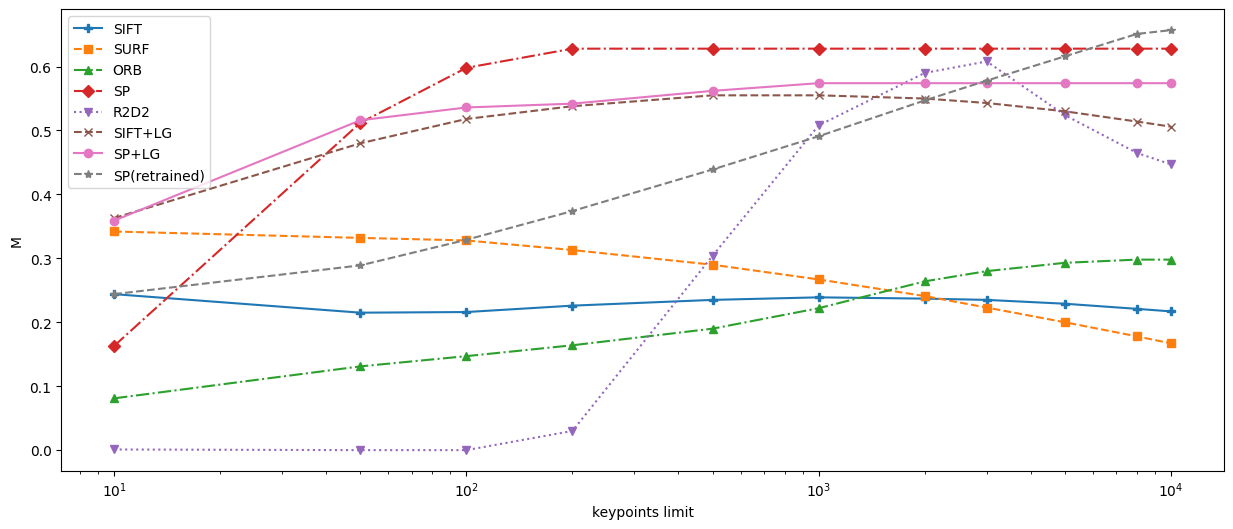

In [11]:
import matplotlib.pyplot as plt
import csv

X = []  # Список для хранения ограничений по оси Х
data = []  # Список для хранения результатов для каждого метода

# Чтение данных из CSV файла с результатами эксперимента
with open('experiment.csv', 'r') as datafile:
    plotting = csv.reader(datafile, delimiter=';')
    
    # Считываем заголовки
    headers = next(plotting)
    
    # Инициализация списков для каждого столбца данных
    for _ in range(len(headers) - 1):
        data.append([])

    # Чтение данных и добавление в список
    for ROWS in plotting:
        X.append(float(ROWS[0]))
        for i in range(len(data)):
            data[i].append(float(ROWS[i + 1]))

# Стили линий и маркеров для графиков
styles = ['-', '--', '-.', '-.', ':', '--', '-', '--']
markers = ['P', 's', '^', 'D', 'v', 'x', 'o','*']

fig, ax = plt.subplots(1, 1, figsize=(15, 6))

# Построение графиков
for i in range(len(data)):
    plt.plot(X, data[i], marker=markers[i % len(markers)], linestyle=styles[i % len(styles)], label=headers[i + 1])

plt.xlabel('keypoints limit')
plt.ylabel('M')
plt.xscale('log')
plt.legend()
plt.show()

На данном графике можно заметить, что после тренировки удалось добиться повышения значения метрики отслеживаемости по сравнению с исходной моделью при извлечении больше 7000 ключевых точек.

Результаты проведенного исследования подтверждают эффективность дообучения модели SuperPoint для задач навигации беспилотных летательных аппаратов в сложных условиях лесистой местности. Из этого можно сделать вывод, что полученная модель может быть успешно встроена в алгоритм навигации БПЛА для повышения его точности. Данная работа открывает новые перспективы для улучшения алгоритмов навигации, что, в свою очередь, может способствовать более безопасному и точному выполнению полетов БПЛА.